In [1]:
import Yokogawa

In [ ]:
Yokogawa.OnCenter(1550)

In [ ]:
Yokogawa.OnSpan(100)

In [ ]:
Yokogawa.OnBandwidth(1)

In [ ]:
Yokogawa.OnRpos(-80)

In [ ]:
Yokogawa.OnRlev(0)

In [ ]:
Yokogawa.OnPdiv(10)

In [ ]:
Yokogawa.OnMax()

In [ ]:
Yokogawa.OnMin()

In [ ]:
Yokogawa.OnMarkCenter()

In [9]:
Yokogawa.OnSingle()

In [ ]:
Yokogawa.OnContinuous()

In [8]:
center = 1550
span = 10
res = 0.05

osa = Yokogawa.AQ6370D(False)
osa.write(f':SENS:WAV:CENT {center}NM')
osa.write(f':SENS:WAV:SPAN {span}NM')
osa.write(f':SENS:BAND:RES {res}NM')
osa.write(':INIT:SMOD REP')
osa.write(':INIT:IMM')
osa.close()

In [ ]:
osa = Yokogawa.AQ6370D(False)
osa.write(f':SENS:SWE:POIN 1001')
osa.write(':INIT:SMOD SING')
osa.write(':INIT:IMM')
x = osa.read(':TRAC:DATA:X? TRA')
y = osa.read(':TRAC:DATA:Y? TRA')
osa.close()

In [ ]:
import numpy as np
x = x.replace('\n', '').split(',')
y = y.replace('\n', '').split(',')
x = np.array(x).astype(float) * 1e9
y = np.array(y).astype(float)

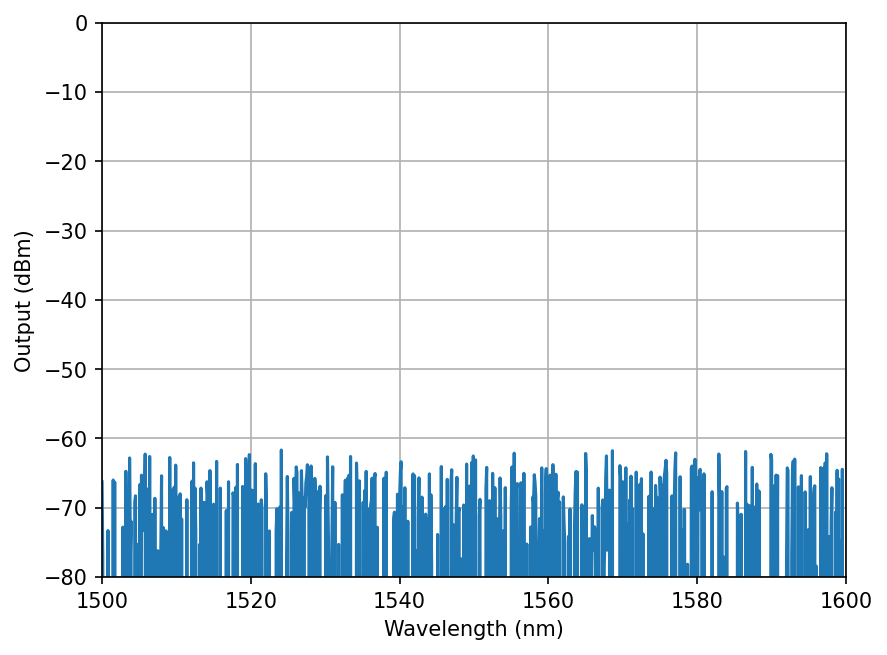

In [ ]:
import matplotlib.pyplot as plt
plt.figure(dpi=150)
plt.plot(x, y)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Output (dBm)')
plt.xlim(1500, 1600)
plt.ylim(-80, 0)
plt.grid()

In [ ]:
filename = '../test'
np.savetxt(f'{filename}.dat', np.array([x, y]).transpose())
plt.savefig(f'{filename}.png')